# Building a neural network FROM SCRATCH (no Tensorflow/Pytorch, just numpy & math)

#### https://www.youtube.com/watch?v=w8yWXqWQYmU

In [72]:
# !pip install --upgrade kaggle
# !pip install --upgrade kagglehub

In [93]:
# # from https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizer
# # Install dependencies as needed:
# # pip install kagglehub[pandas-datasets]
# import kagglehub
# from kagglehub import KaggleDatasetAdapter
# import os
# from pathlib import Path

# # Set the path to the file you'd like to load
# file_name = 'mnist_dataset.csv'
# file_path = os.path.join(Path.home(), 'OneDrive - Prescient\py\kaggle_datasets', file_name)

# # Load the latest version
# df = kagglehub.load_dataset(
#   KaggleDatasetAdapter.PANDAS,
#   "animatronbot/mnist-digit-recognizer",
#   file_path,
#   # Provide any additional arguments like 
#   # sql_query or pandas_kwargs. See the 
#   # documenation for more information:
#   # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
# )

# print("First 5 records:", df.head())

In [95]:
# # from: https://www.kaggle.com/datasets/animatronbot/mnist-digit-recognizerimport kagglehub

# import kagglehub
# import os
# from pathlib import Path

# # Download latest version
# path = kagglehub.dataset_download("animatronbot/mnist-digit-recognizer")

# print("Path to dataset files:", path)

In [4]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from matplotlib import pyplot as plt

In [5]:
file_folder = 'OneDrive - Prescient\py\kaggle_datasets'
file_name   = 'train.csv'
data        = pd.read_csv(os.path.join(Path.home(), file_folder, file_name))
examples, features = data.shape
print(f'{examples} rows of examples, {features-1} columns of features')

42000 rows of examples, 784 columns of features


In [6]:
# convert the dataset into a numpy array, randomise across the examples (in rows)
data = np.array(data)
np.random.shuffle(data)

# transform the array to have the examples as column vectors
data = data.T # tandform the datastet to have labels in the top row
# np.info(data)

In [8]:
# split the dataset into a test (dev, cross-validation) set and a training set
tst, trn = (1, 13) # proportion of test set to training set
M = int(tst / trn * examples)  # = 1,000 = test set size
data_test = data[:,0:M]    # first 100 columns of examples in the dataset
Y_test    = data_test[0]   # first row of the sampled dataset, data_dev
X_test    = data_test[1:M] # remaining (M =) 1000 rows of the dataset, data_dev
X_test    = X_test / 255   # 0 (black) to 255 (white) shades of grey
print(data_test.shape, Y_test.shape, X_test.shape)

(785, 3230) (3230,) (784, 3230)


In [9]:
# make a training set of the remainder of the dataset
data_train = data[:,M:examples]
Y_train = data_train[0] # first row of the test dataset, data_dev
X_train = data_train[1:,] # remaining rows
X_train = X_train / 255. # 256 shades of grey from 0 (black) to 255 (white)
print(data_train.shape, Y_train.shape, X_train.shape)

(785, 38770) (38770,) (784, 38770)


In [10]:
# instantiate initial weights and biases for an input layer (w1, b1) and a 2nd layer (w2, b2) in the neural network
def init_params():
    w1 = np.random.rand(10, 784) - .5 # generates a 2-D array with 10 rows, each row containing 784 random numbers:
    b1 = np.random.rand(10, 1  ) - .5
    w2 = np.random.rand(10, 10 ) - .5
    b2 = np.random.rand(10, 1  ) - .5
    return w1, b1, w2, b2

# The Rectified Linear Unit (ReLU) function is a widely used 
# activation function that introduces the property of non-linearity
# to a deep learning model and solves the vanishing gradients
# issue. It introduces non-linearity into the network, 
# allowing it to learn complex patterns
def ReLU(z):  
    return np.maximum(0, z)
    
# The derivative of the ReLU (Rectified Linear Unit) function 
# is a piecewise function that returns 1 for inputs greater 
# than zero and 0 for inputs less than or equal to zero. 
# While the theoretical derivative is undefined at x=0 due 
# to the sharp "kink" in the graph, in practice, deep learning 
# frameworks typically assign a value of 0 or 1 for the 
# derivative at x=0 to handle the computation.
def ReLU_deriv(z):
    return z > 0

# The softmax function, also known as softargmax or normalized 
# exponential function, is a mathematical function that transforms a 
# vector of real numbers into a probability distribution. This means it 
# converts a set of raw scores (often called "logits" in machine 
# learning) into a set of probabilities, where each probability is 
# between 0 and 1, and all probabilities sum to 1.
# For an input vector x = [x_1, x_2, ..., x_k]
# the softmax function calculates the probability 
# p_i for each element x_i as follows:
# p_i = exp(x_i) / sum(exp(x_j) for j in range(k))
def softmax(z):
    return np.exp(z) / sum(np.exp(z))

# One-hot encoding is a technique used in machine learning to 
# convert categorical data into a numerical format that machine 
# learning algorithms can understand. It represents each category 
# as a binary vector, where only one element is "1" (representing
# the presence of that category), and the rest are "0"
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def fwd_prpgn(w1, b1, w2, b2, X):
    z1 = w1.dot(X) + b1
    a1 = ReLU(z1)
    z2 = w2.dot(a1) + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2

def bwd_prpgn(z1, a1, z2, a2, w1, w2, X, Y):
    one_hot_Y = one_hot(Y)
    dz2 = a2 - one_hot_Y # error in the output (2nd) layer is the result of the forward propagation values less the actual values
    dw2 = 1 / examples * dz2.dot(a1.T)
    db2 = 1 / examples * np.sum(dz2)
    dz1 = w2.T.dot(dz2) * ReLU_deriv(z1)
    dw1 = 1 / examples * dz1.dot(X.T)
    db1 = 1 / examples * np.sum(dz1)
    return dw1, db1, dw2, db2

def update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha):
    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1
    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2
    return w1, b1, w2, b2

In [21]:
def get_predictions(a2):
    return np.argmax(a2, 0)

def get_accuracy(predictions, Y):
    # print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    w1, b1, w2, b2 = init_params()
    for i in range(iterations):
        z1, a1, z2, a2     = fwd_prpgn(w1, b1, w2, b2, X)
        dw1, db1, dw2, db2 = bwd_prpgn(z1, a1, z2, a2, w1, w2, X, Y)
        w1, b1, w2, b2     = update_params(w1, b1, w2, b2, dw1, db1, dw2, db2, alpha)
        if i % 10 == 0:
            # print(f'Iteration {i} of {iterations}')
            predictions = get_predictions(a2)
            print(f'{get_accuracy(predictions, Y)*100:,.3f}% after iteration {i} of {iterations}')
    return w1, b1, w2, b2

In [22]:
w1, b1, w2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

6.634% after iteration 0 of 500
13.059% after iteration 10 of 500
18.837% after iteration 20 of 500
21.272% after iteration 30 of 500
23.928% after iteration 40 of 500
27.026% after iteration 50 of 500
30.178% after iteration 60 of 500
33.526% after iteration 70 of 500
36.949% after iteration 80 of 500
39.936% after iteration 90 of 500
41.826% after iteration 100 of 500
43.704% after iteration 110 of 500
45.860% after iteration 120 of 500
48.176% after iteration 130 of 500
50.498% after iteration 140 of 500
52.840% after iteration 150 of 500
55.130% after iteration 160 of 500
57.614% after iteration 170 of 500
60.586% after iteration 180 of 500
63.766% after iteration 190 of 500
66.533% after iteration 200 of 500
68.765% after iteration 210 of 500
70.508% after iteration 220 of 500
71.842% after iteration 230 of 500
72.837% after iteration 240 of 500
73.810% after iteration 250 of 500
74.736% after iteration 260 of 500
75.522% after iteration 270 of 500
76.208% after iteration 280 of 5

In [23]:
# define prediction testing functions

def make_predictions(X, w1, b1, w2, b2):
    _, _, _, a2 = fwd_prpgn(w1, b1, w2, b2, X)
    predictions = get_predictions(a2)
    return predictions

def test_prediction(index, w1, b1, w2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], w1, b1, w2, b2)
    print("Prediction: ", prediction)
    print("Label: ", Y_train[index])
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation = 'nearest')
    plt.show()

Prediction:  [0]
Label:  0


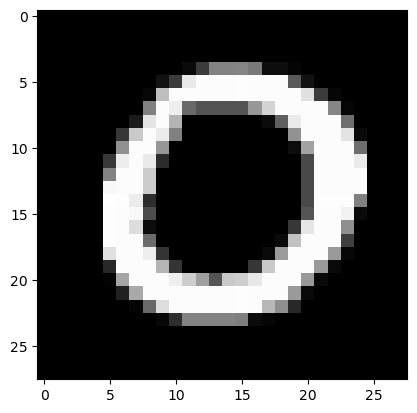

Prediction:  [3]
Label:  3


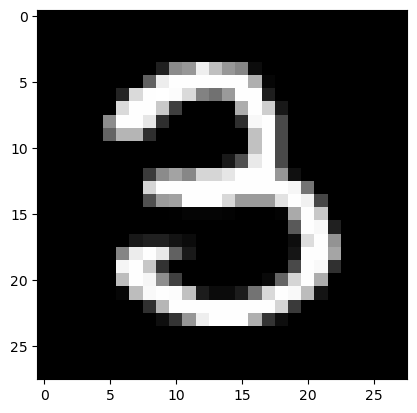

Prediction:  [9]
Label:  9


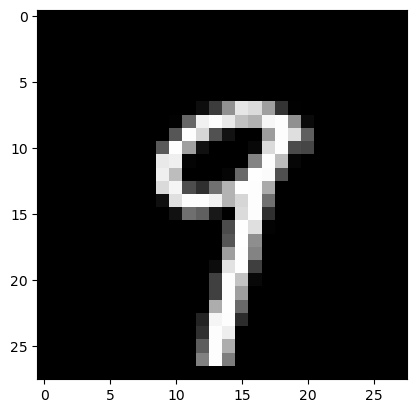

Prediction:  [8]
Label:  9


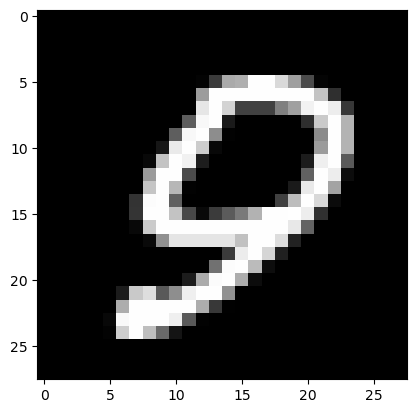

In [24]:
# test a sample set of predictions
test_prediction(0, w1, b1, w2, b2)
test_prediction(1, w1, b1, w2, b2)
test_prediction(2, w1, b1, w2, b2)
test_prediction(3, w1, b1, w2, b2)

In [91]:
# Finally, let's find the accuracy on the test / dev set:
dev_predictions = make_predictions(X_test, w1, b1, w2, b2)
get_accuracy(dev_predictions, Y_test)

[9 8 8 6 8 8 9 8 0 6 9 1 9 3 3 8 7 2 0 5 7 5 4 4 9 2 6 0 0 0 2 8 3 2 2 0 6
 3 2 5 6 8 2 5 8 0 2 9 8 2 0 9 7 2 3 3 6 3 5 0 4 3 8 2 6 5 2 4 8 7 5 5 0 6
 1 8 9 2 0 7 5 0 4 5 7 2 3 3 1 8 2 1 4 2 8 8 8 6 1 1 7 5 2 3 9 9 7 3 4 0 0
 4 9 6 5 3 9 6 7 1 7 5 9 9 8 3 7 3 9 2 4 2 3 8 8 8 6 4 7 6 4 4 8 7 1 7 0 5
 7 6 0 6 4 6 7 1 6 5 3 1 3 0 0 9 9 6 0 1 4 8 1 1 4 4 2 4 2 0 9 9 5 7 6 4 3
 3 9 3 6 1 4 4 3 1 5 2 1 7 5 5 1 0 0 8 5 6 7 8 0 9 6 9 1 2 0 9 6 2 4 7 6 1
 9 5 6 4 9 7 2 2 1 1 2 4 7 3 1 2 7 4 4 3 0 1 9 0 4 1 2 9 3 6 6 3 1 1 1 0 5
 7 8 0 9 3 4 0 1 1 3 6 5 4 3 1 4 1 1 7 2 5 9 8 8 6 2 9 9 1 9 8 9 3 7 7 3 1
 0 2 1 6 2 9 0 3 0 5 8 1 3 9 5 3 0 5 9 8 9 9 3 6 4 0 1 7 2 1 3 6 4 9 7 0 6
 4 0 8 4 3 6 0 6 0 3 0 6 6 2 6 6 9 6 0 2 8 4 1 0 7 2 3 7 2 1 1 7 3 6 5 7 8
 9 4 5 8 7 9 1 6 6 3 4 0 1 2 7 5 2 1 4 1 4 2 6 0 8 4 2 7 7 5 5 5 3 4 9 2 3
 0 9 8 1 1 1 3 1 8 0 6 6 6 9 1 2 7 1 0 2 4 9 9 0 6 7 3 5 4 4 9 7 8 1 1 9 1
 2 4 0 5 2 6 6 6 4 2 0 1 0 1 7 6 3 8 3 4 7 4 4 9 1 2 6 9 5 2 7 9 5 3 2 3 0
 3 3 6 7 1 6 8 8 7 0 3 1 

0.846

In [25]:
# !jupyter nbconvert --to script mnist_manually.ipynb

[NbConvertApp] Converting notebook mnist_manually.ipynb to script
[NbConvertApp] Writing 7920 bytes to mnist_manually.py
